# Product Review Sentiment Analysis

This project explores modern Natural Language Processing (NLP) techniques to analyze sentiment in product reviews. We use two distinct approaches using Transformer-based models:

1.  **Binary Classification:** Using DistilBERT to predict **positive or negative** sentiment directly.
2.  **Granular Star-Mapping:** Using a Multilingual BERT model to predict **1-5 star** ratings.

# Part 1: Environment Setup
## Authentication and Configuration
To begin, we authenticate with the Hugging Face Hub to ensure we have access to the transformer models used in this analysis.

In [ ]:
from huggingface_hub import login

login()

# Part 2: Data Acquisition & Preprocessing
## Dataset: Amazon Polarity

We utilize the Amazon Polarity dataset, which provides a large-scale benchmark for binary sentiment classification based on customer reviews.

- **Size:** ~3.6 million training samples and 400,000 test samples.
- **Origin:** Constructed by Xiang Zhang et al. (2015) from ~35 million Amazon customer reviews collected over an 18-year period.
- **Fields:** Each entry contains a `title`, `content` (review text), and `label` (0 = Negative, 1 = Positive).
- **Products covered:** Reviews span a wide range of Amazon product categories, like books, electronics, home & kitchen, toys, music, movies, clothing, beauty, and more.

**Label Construction**

The dataset is built from the original 1–5 star ratings as follows:
- **1–2 stars** → Negative (label = 0)
- **4–5 stars** → Positive (label = 1)
- **3-stars** reviews are excluded entirely — they are considered neutral/ambiguous and do not appear in the dataset.

**Source:** https://huggingface.co/datasets/fancyzhx/amazon_polarity

In [ ]:
from datasets import load_dataset, get_dataset_split_names

# Check the available splits in the original dataset
splits = get_dataset_split_names("fancyzhx/amazon_polarity")
print(f"Original dataset splits: {splits}")

# We use the 'train' split and select a 10-row subset for model evaluation
ds = load_dataset("fancyzhx/amazon_polarity", split="train").shuffle().select(range(10))

# Save the 10-row sample as CSV
# ds.to_csv("amazon_polarity_sample.csv", index=False)
# print(f"CSV file saved")

Original dataset splits: ['train', 'test']


In [ ]:
import pandas as pd

df_amazon = ds.to_pandas()

# Clean and rename
df_amazon = df_amazon.drop(columns=['title'])
df_amazon = df_amazon.rename(columns={'content': 'review_content', 'label': 'sentiment_label'})
df_amazon = df_amazon[['review_content', 'sentiment_label']]

print(f"Rows in DataFrame: {len(df_amazon)}")
display(df_amazon.head())

Rows in DataFrame: 10


,review_content,sentiment_label
0,I have the Bandit product and got another one ...,0
1,"Between them suing their own fans , Becoming M...",0
2,THis was supposed to come with a CD and it did...,0
3,Ive bought the CD Enlightin'ment by Lou Christ...,1
4,What a pleasure - to discover some new classic...,1


# Part 3: Model 1 - Binary Classification
## Pipeline: DistilBERT (Fine-tuned on SST-2)

In this section, we implement a lightweight DistilBERT model specifically fine-tuned for binary sentiment analysis to predict 'Positive' or 'Negative' labels directly.

In [ ]:
from transformers import pipeline
from google.colab import userdata
import os

# Load token securely from Colab Secrets
os.environ["HUGGINGFACE_TOKEN"] = userdata.get('HF_TOKEN')

# Load a pre-trained sentiment analysis model
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
)

# Extract all rows
sentences = df_amazon['review_content'].tolist()

print(f"Analyzing all {len(sentences)} reviews:\n")

for i, sentence in enumerate(sentences):
    result = sentiment_pipeline(sentence)[0]
    print(f"Review {i+1}: {sentence[:100]}...")
    print(f"Predicted: {result['label']} (Confidence Score: {result['score']:.4f})")
    print("-" * 50)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Analyzing all 10 reviews:

Review 1: I have the Bandit product and got another one but wanted something that I can alternate and wear at ...
Predicted: NEGATIVE (Confidence Score: 0.9978)
--------------------------------------------------
Review 2: Between them suing their own fans , Becoming MTV Puppets , Touring with the most recent "in" bands ,...
Predicted: NEGATIVE (Confidence Score: 0.9997)
--------------------------------------------------
Review 3: THis was supposed to come with a CD and it did not come with one. Please send it ! The whole idea of...
Predicted: NEGATIVE (Confidence Score: 0.9990)
--------------------------------------------------
Review 4: Ive bought the CD Enlightin'ment by Lou Christie and the songs are all awsome. He has one of the bes...
Predicted: POSITIVE (Confidence Score: 0.9987)
--------------------------------------------------
Review 5: What a pleasure - to discover some new classical music to me and to find out that this George Anthei...
Predicted: 

**Manual: Setting Up the Hugging Face Token in Google Colab Secrets**

1. Click the key key icon in the left sidebar of Colab.
2. Click + Add new secret.
Name it exactly HF_TOKEN.
3. Paste the Hugging Face token as the value.
4. Toggle Notebook access ON for that secret.
5. Re-run the cell.

# Part 4: Model 2 - Multi-class Star Mapping
## Pipeline: BERT Multilingual (Star Ratings)

We contrast the previous model with a more granular BERT model that predicts specific star ratings (1–5). We then apply custom logic to map these stars back into binary sentiment categories.

In [ ]:
from transformers import pipeline
from google.colab import userdata
import os

# Load token securely from Colab Secrets
os.environ["HUGGINGFACE_TOKEN"] = userdata.get('HF_TOKEN')

# This model outputs 1–5 star ratings
star_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

# Extract all rows
sentences = df_amazon['review_content'].tolist()

print(f"Evaluating all {len(sentences)} reviews with Star Rating Model:\n")

for i, review in enumerate(sentences):
    result = star_pipeline(review)[0]
    print(f"Review {i+1}: {review[:100]}...")
    print(f"Predicted: {result['label']} (Confidence Score: {result['score']:.4f})")
    print("-" * 50)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Evaluating all 10 reviews with Star Rating Model:

Review 1: I have the Bandit product and got another one but wanted something that I can alternate and wear at ...
Predicted: 4 stars (Confidence Score: 0.3966)
--------------------------------------------------
Review 2: Between them suing their own fans , Becoming MTV Puppets , Touring with the most recent "in" bands ,...
Predicted: 1 star (Confidence Score: 0.9099)
--------------------------------------------------
Review 3: THis was supposed to come with a CD and it did not come with one. Please send it ! The whole idea of...
Predicted: 1 star (Confidence Score: 0.7300)
--------------------------------------------------
Review 4: Ive bought the CD Enlightin'ment by Lou Christie and the songs are all awsome. He has one of the bes...
Predicted: 5 stars (Confidence Score: 0.6820)
--------------------------------------------------
Review 5: What a pleasure - to discover some new classical music to me and to find out that this George Ant

# Part 5: Performance Analysis & Metrics

By comparing both models against the ground truth labels, we visualize their effectiveness through Accuracy Scores and Confusion Matrices.

**Note:**

The accuracy is not the model’s trained performance; instead, it varies and shows different results each time for different product reviews against the true label.


Running inference on 10 reviews...


  0%|          | 0/10 [00:00<?, ?it/s]

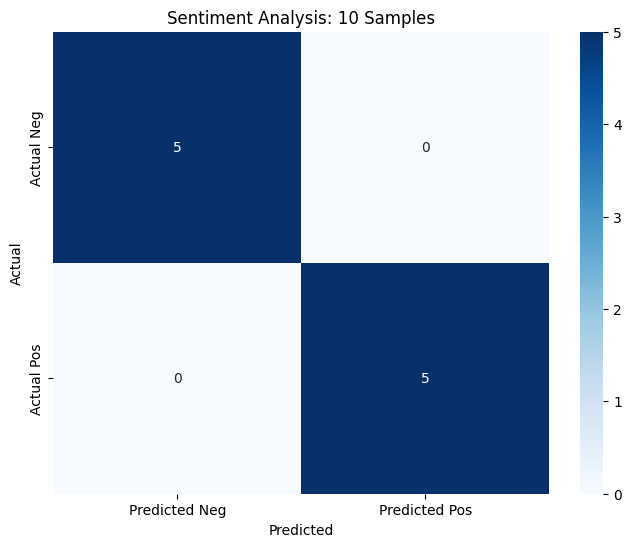

Final Accuracy Score: 100.0%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from tqdm.auto import tqdm

# Prepare labels
map_model_labels = { 'NEGATIVE': 0, 'POSITIVE': 1 }
y_true = df_amazon['sentiment_label'].tolist()
y_pred = []
sentences = df_amazon['review_content'].tolist()

print(f"Running inference on {len(sentences)} reviews...")
for sentence in tqdm(sentences):
    res = sentiment_pipeline(sentence)[0]
    y_pred.append(map_model_labels[res['label']])

# Metrics and Visualization
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

plt.title(f'Sentiment Analysis: {len(y_true)} Samples')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"Final Accuracy Score: {acc*100:.1f}%")

It predicts sentiment for each review with sentiment_pipeline, maps the 'POSITIVE'/'NEGATIVE' outputs to 0/1, then compares against the true labels using accuracy_score and a confusion_matrix visualized as a heatmap.

**What each number means:**

|                | Predicted Neg | Predicted Pos |
|----------------|---------------|---------------|
| **Actual Neg** | TN            | FP            |
| **Actual Pos** | FN            | TP            |

- TN = Negative reviews correctly predicted as negative.
- FP = Negative reviews wrongly flagged as positive.
- FN = Positive review wrongly predicted as negative.
- TP = Positive reviews correctly predicted as positive.

**Key metrics:**

Accuracy = [(TN + TP) / Total] × 100

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running star-rating inference on 10 reviews...


  0%|          | 0/10 [00:00<?, ?it/s]

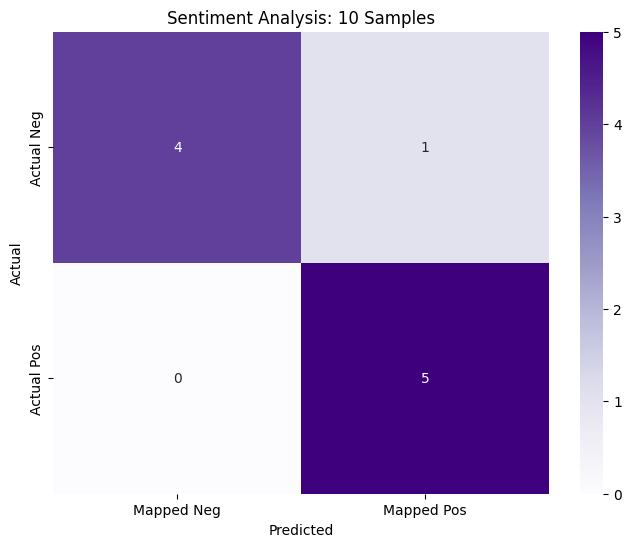

Final Accuracy Score: 90.0%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tqdm.auto import tqdm
from transformers import pipeline

# Initialize the star-rating pipeline
star_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

# Extract labels and reviews
y_true_raw = df_amazon['sentiment_label'].tolist()
sentences = df_amazon['review_content'].tolist()
total = len(sentences)

y_true_filtered = []
y_pred_mapped = []
fails = 0

print(f"Running star-rating inference on {total} reviews...")
for i, sentence in enumerate(tqdm(sentences)):
    res = star_pipeline(sentence)[0]
    stars = int(res['label'].split(' ')[0])

    # Mapping Logic:
    # 1-2 stars = negative (0)
    # 4-5 stars = positive (1)
    # 3 stars   = automatic fails
    if stars in [1, 2]:
        y_pred_mapped.append(0)
        y_true_filtered.append(y_true_raw[i])
    elif stars in [4, 5]:
        y_pred_mapped.append(1)
        y_true_filtered.append(y_true_raw[i])
    else:
        fails += 1

# Accuracy: correct predictions / TOTAL reviews
correct = sum(p == t for p, t in zip(y_pred_mapped, y_true_filtered))
acc = correct / total

# Confusion matrix on the non-failed samples
cm = confusion_matrix(y_true_filtered, y_pred_mapped)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Mapped Neg', 'Mapped Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

plt.title(f'Sentiment Analysis: {len(y_true)} Samples')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"Final Accuracy Score: {acc*100:.1f}%")

Each review is run through a 1–5 stars BERT model, which maps 1–2 stars → negative (0) and 4–5 stars → positive (1), then evaluated against the true labels via accuracy and a confusion matrix.

**Note:**

3 stars outputs count as automatic fails (excluded from the matrix but kept in the accuracy denominator) because the dataset already excluded neutral reviews.

# Part 6: Conceptual Discussion
This section discusses the key trade-offs and design choices behind the sentiment analysis performed.


**Why no Text Preprocessing?**

Modern Transformer models (BERT, DistilBERT) use subword tokenizers that handle punctuation, and special characters internally. Manual preprocessing (like removing stop words or lemmatization) can actually destroy the contextual cues these models rely on to understand sentiment.

**Does the Split Matter?**

Usually, we use the 'test' split (original dataset) for final evaluation to ensure the model isn't just 'memorizing' data it saw during training. Since we are using pre-trained models and just testing their performance (inference) on 10 random samples, either split works. The results would be statistically similar for this specific task.

**Model Insights**

The results show a higher confidence score for the DistilBERT model over BERT, which is expected since DistilBERT is fine-tuned specifically for binary sentiment classification. BERT, on the other hand, distributes its probability across five star ratings, so its confidence is naturally diluted even when the prediction is correct.


# Part 7: Interactive Deployment
## Live Sentiment Inference

Finally, we provide an interactive interface to test both models against custom, real-time user inputs.

In [ ]:
#@title Interactive Sentiment Analysis Tool
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from collections import Counter

# Configuration
MAX_REVIEWS = 10
review_widgets = [widgets.Text(placeholder='Enter review 1...', layout=widgets.Layout(width='80%'))]
container = widgets.VBox(review_widgets)
add_button = widgets.Button(description="Add Review", button_style='info', icon='plus')
run_button = widgets.Button(description="Analyze All", button_style='success', icon='check')
output = widgets.Output()

def get_confidence_level(score):
    if score >= 0.9: return "Very Confident"
    elif score >= 0.6: return "Confident"
    elif score >= 0.4: return "Moderate"
    elif score >= 0.1: return "Low"
    else: return "Very Low"

def add_review_field(b):
    if len(review_widgets) < MAX_REVIEWS:
        new_id = len(review_widgets) + 1
        new_widget = widgets.Text(placeholder=f'Enter review {new_id}...', layout=widgets.Layout(width='80%'))
        review_widgets.append(new_widget)
        container.children = tuple(review_widgets)
    if len(review_widgets) == MAX_REVIEWS:
        add_button.disabled = True

def run_analysis(b):
    with output:
        clear_output()
        reviews = [w.value.strip() for w in review_widgets if w.value.strip()]

        if not reviews:
            print("Please enter at least one review.")
            return

        print(f"Analyzing {len(reviews)} reviews...\n")
        distil_sentiments = []
        star_labels = []
        distil_scores = []
        star_scores  = []

        for i, text in enumerate(reviews):
            res_distil = sentiment_pipeline(text)[0]
            label = res_distil['label']
            distil_sentiments.append(label)

            distil_score = res_distil['score']
            distil_level = get_confidence_level(distil_score)
            distil_scores.append(distil_score)

            res_star = star_pipeline(text)[0]
            star_score = res_star['score']
            star_level = get_confidence_level(star_score)
            star_labels.append(res_star['label'])
            star_scores.append(star_score)

            print(f"Review {i+1}: '{text[:50]}...'")
            print(f"  -> [DistilBERT]: {label} | Score: {distil_score:.4f} ({distil_level})")
            print(f"  -> [BERT Star]:  {res_star['label']} | Score: {star_score:.4f} ({star_level})")
            print("-" * 50)

        # Average confidence per model
        avg_distil = sum(distil_scores) / len(distil_scores)
        avg_star   = sum(star_scores) / len(star_scores)

        # Visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        # 1. Binary Distribution Pie Chart
        counts_bin = Counter(distil_sentiments)
        ax1.pie(list(counts_bin.values()), labels=list(counts_bin.keys()), autopct='%1.1f%%', startangle=140, colors=['#2ecc71', '#e74c3c'])
        ax1.set_title(f'Binary Sentiment Distribution\nAvg Confidence: {avg_distil:.4f} ({get_confidence_level(avg_distil)})')

        # 2. Star Distribution Pie Chart
        counts_star = Counter(star_labels)
        sorted_keys = sorted(counts_star.keys())
        star_sizes = [counts_star[k] for k in sorted_keys]
        ax2.pie(star_sizes, labels=sorted_keys, autopct='%1.1f%%', startangle=140, colors=plt.cm.RdYlGn(range(0, 256, 256//5)))
        ax2.set_title(f'Star Rating Distribution\nAvg Confidence: {avg_star:.4f} ({get_confidence_level(avg_star)})')

        plt.tight_layout()
        plt.show()

add_button.on_click(add_review_field)
run_button.on_click(run_analysis)

print("Enter your product review(s) (Max 10):")
display(container, widgets.HBox([add_button, run_button]), output)

Enter your product review(s) (Max 10):


Output()

# Conclusion
This project successfully demonstrated how different transformer architectures handle sentiment analysis. By comparing direct binary classification with granular star-rating mapping, we've shown the versatility and accuracy of modern NLP models in real-world scenarios.

# Resources

* [DistilBERT Documentation](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english)
* [Multilingual BERT Documentation](https://huggingface.co/nlptown/bert-base-multilingual-uncased-sentiment)